# Arbitrage index

Given the reference trade sizes, price the executable cross-pool round trip and
summarize it into a per-pool-pair arbitrage index. Parameters come from
`arblib.config.STUDY`.

In [1]:
from arblib import data_io, analysis, sizing, arbitrage, plotting
from arblib.config import STUDY as S

pools = data_io.load_processed_pools(S.processed_dir)
analysis.add_mid_price(pools)

prices = data_io.load_usd_prices(S.prices_path)
const = sizing.constant_usd_prices(prices)
price0 = float(const[S.token0.address])
price1 = float(const[S.token1.address])

quantiles = data_io.load_quantiles(S.quantiles_path)
print(quantiles)

Loaded 7 processed pools: ['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'pancake_1', 'pancake_2']
quantile
0.2      63.195045
0.4     313.031954
0.6     740.312922
0.8    1857.293128
Name: usd, dtype: float64


## 1. Cross-DEX mid-price gaps

The raw opportunity before execution costs: per-pool mid prices and the absolute
price difference for every cross-DEX pool pair.

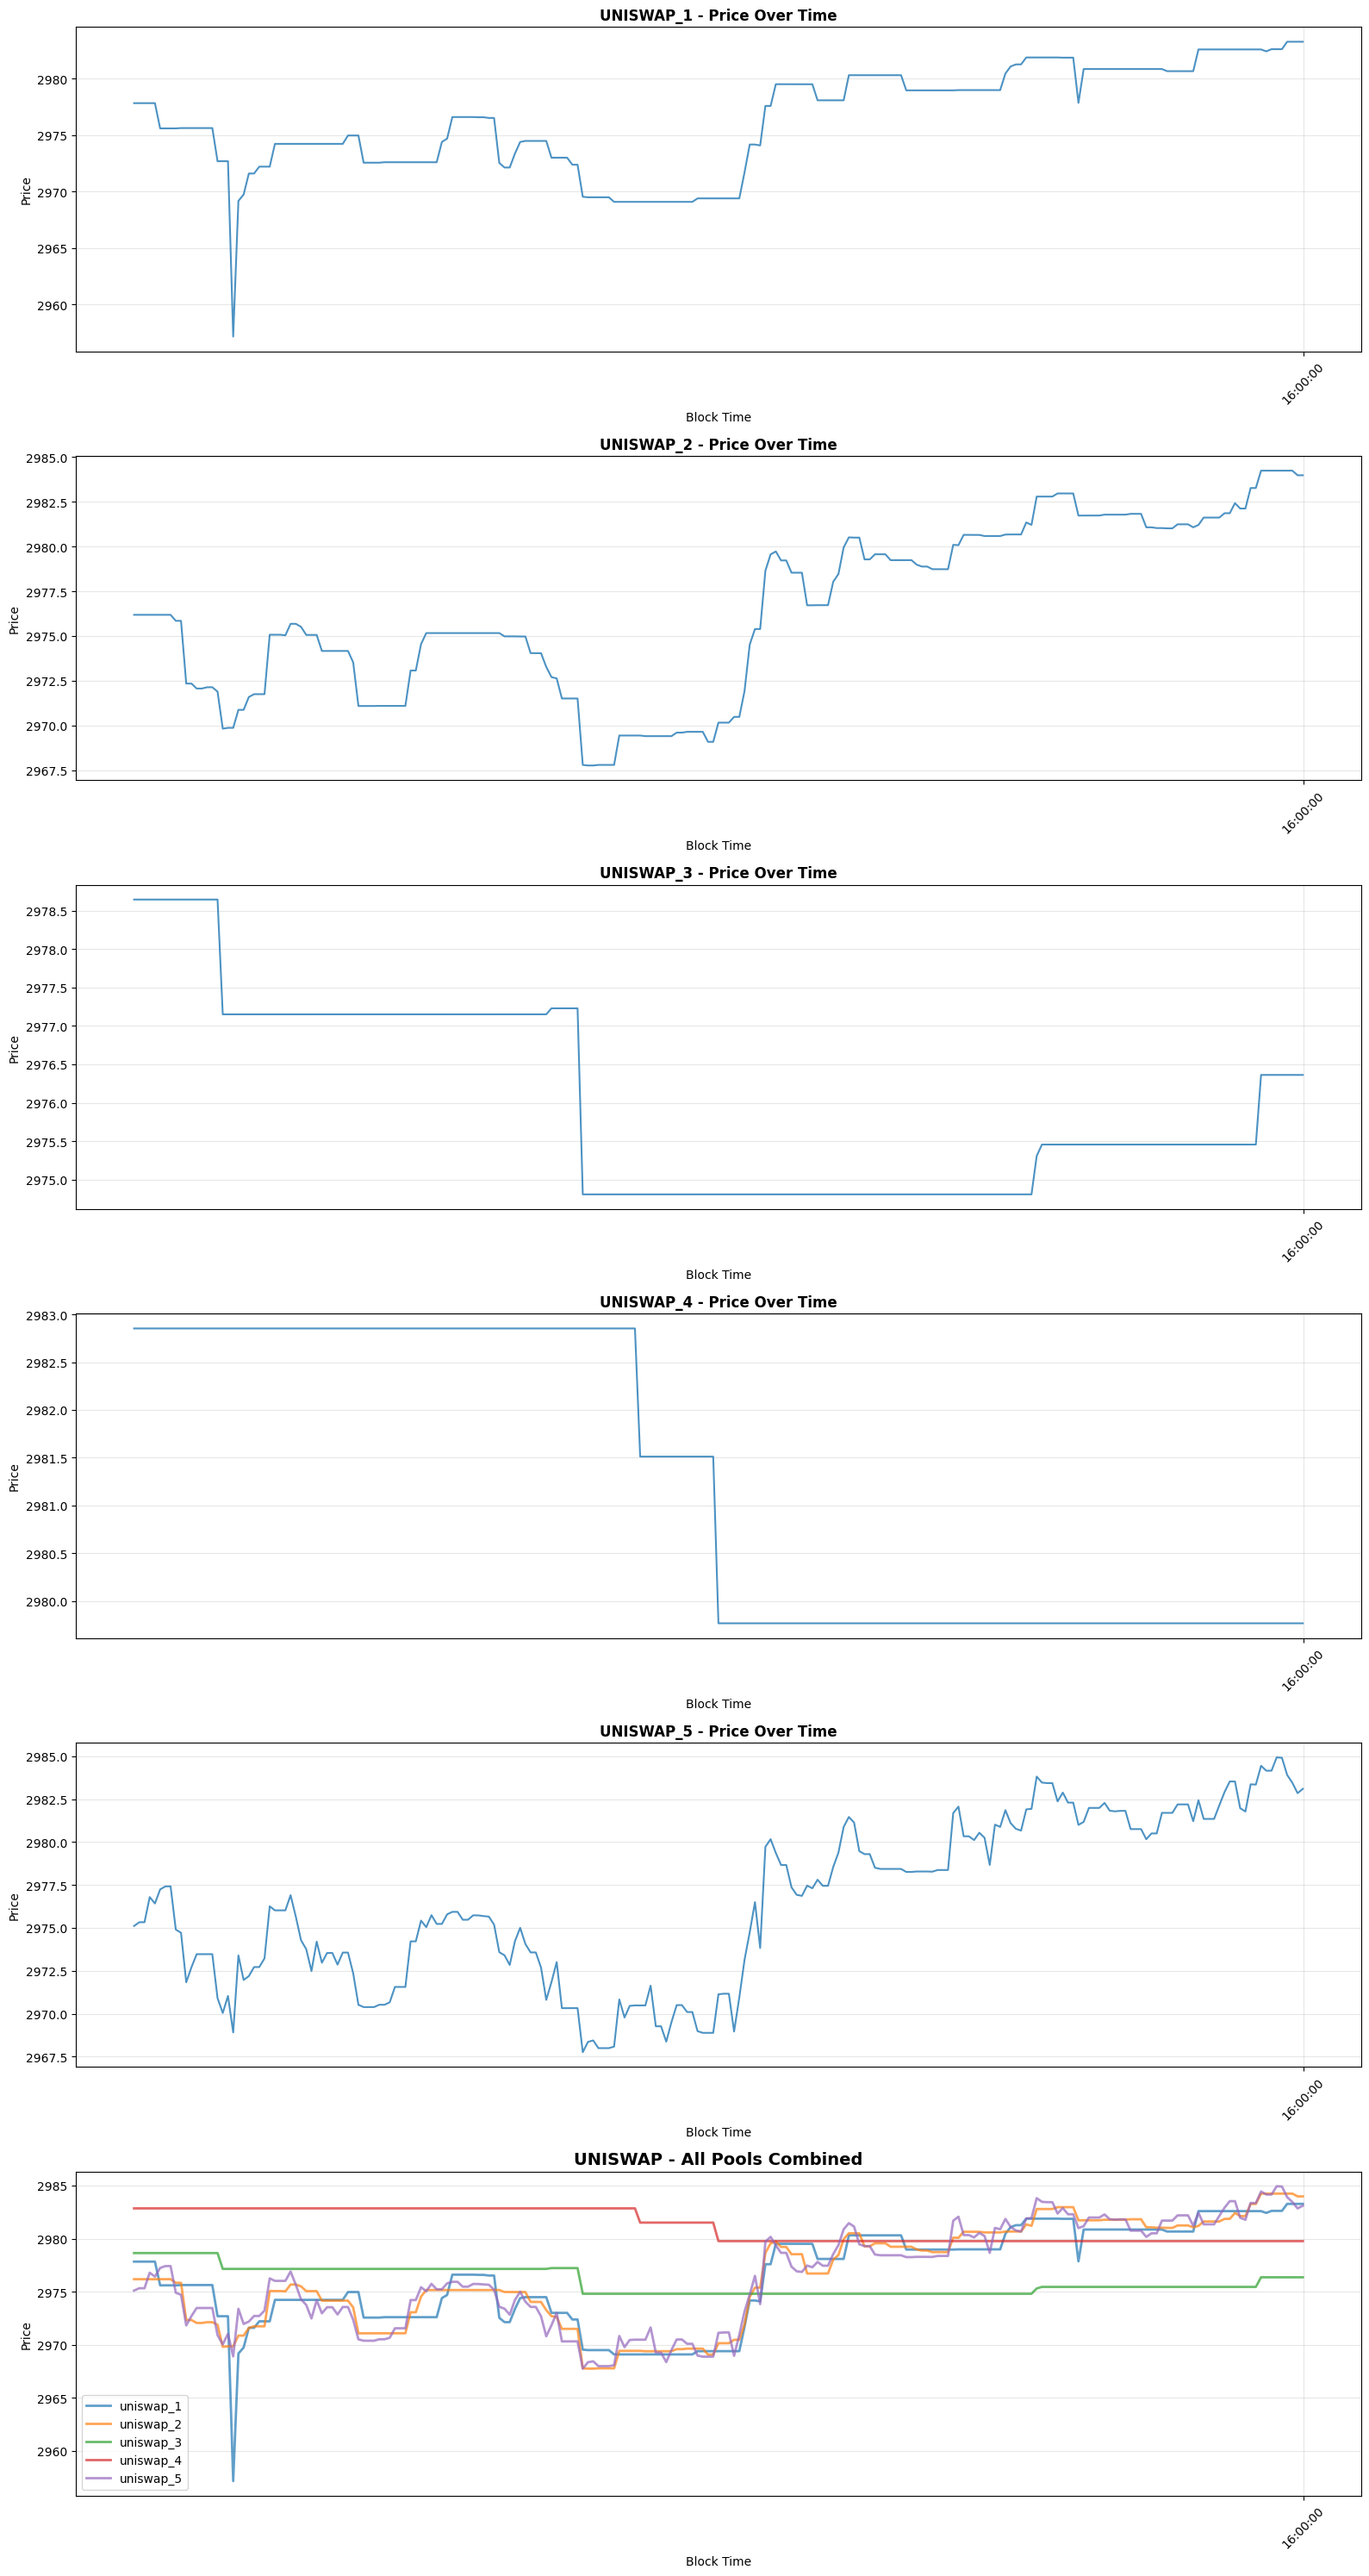


Plotted 5 uniswap pools + 1 combined view
  uniswap_1: 225 blocks
  uniswap_2: 225 blocks
  uniswap_3: 225 blocks
  uniswap_4: 225 blocks
  uniswap_5: 225 blocks


In [2]:
plotting.plot_dex_pools(pools, dex="uniswap")

In [3]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 5), ('pancake', 2)]

Computed 10 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 225
  Max diff: 12.931532
  Mean diff: 1.391070
  Min diff: 0.019574

uniswap_1_vs_pancake_2:
  Rows: 225
  Max diff: 12.718176
  Mean diff: 1.015642
  Min diff: 0.010093

uniswap_2_vs_pancake_1:
  Rows: 225
  Max diff: 2.730908
  Mean diff: 0.836662
  Min diff: 0.010508

uniswap_2_vs_pancake_2:
  Rows: 225
  Max diff: 2.434724
  Mean diff: 0.555870
  Min diff: 0.000000

uniswap_3_vs_pancake_1:
  Rows: 225
  Max diff: 8.747698
  Mean diff: 4.804879
  Min diff: 0.385545

uniswap_3_vs_pancake_2:
  Rows: 225
  Max diff: 7.560673
  Mean diff: 4.859384
  Min diff: 0.295219

uniswap_4_vs_pancake_1:
  Rows: 225
  Max diff: 16.792415
  Mean diff: 6.217794
  Min diff: 0.091231

uniswap_4_vs_pancake_2:
  Rows: 225
  Max diff: 15.605390
  Mean diff: 6.046429
  Min diff: 0.186214

uniswap_5_vs_pancake_1:
  Rows: 225
  Max diff: 4.224619
  Mean diff

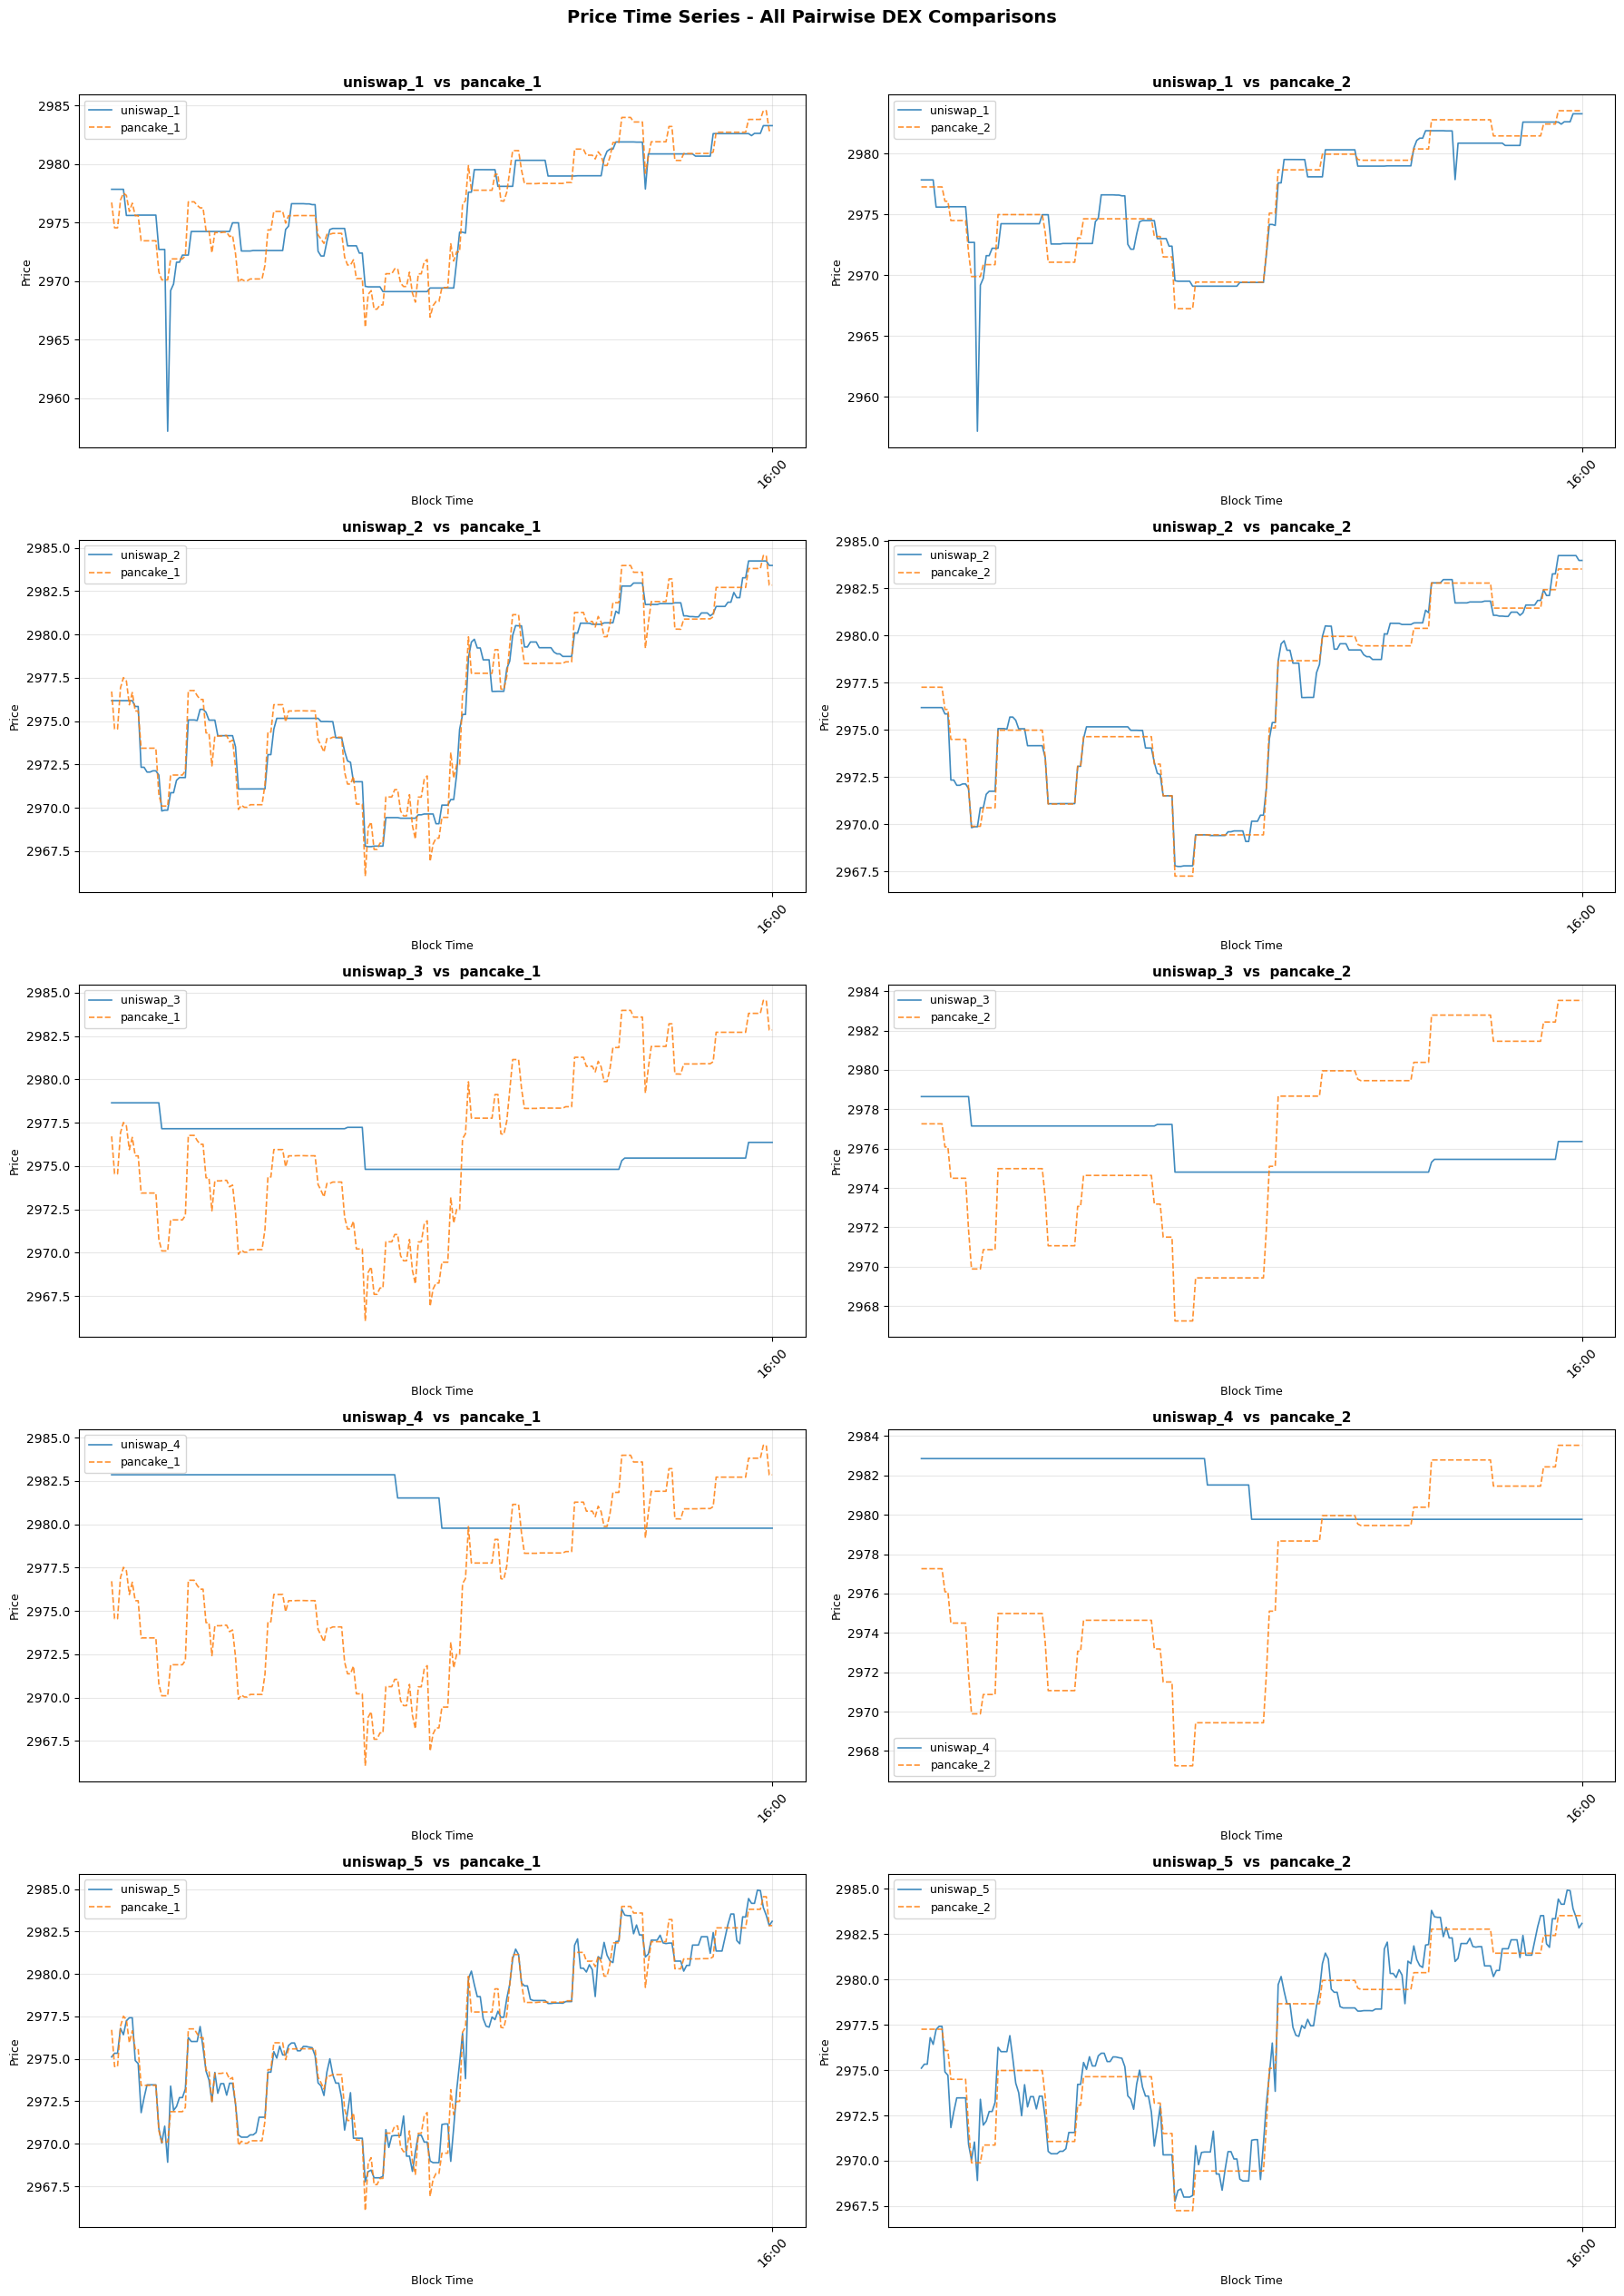

In [4]:
plotting.plot_pairwise_prices(price_differences)

## 2. Pick a pool pair

Bundle two pools' per-block state + market context into a `PoolPair`.

In [5]:
pair = arbitrage.build_pool_pair(
    pools["pancake_1"], pools["uniswap_1"], S.token0, S.token1, price0, price1, "pancake_1", "uniswap_1"
)

## 3a. Round-trip spreads at each reference trade size

Two panels per size (direction 1→2 and 2→1, Y- and X-anchored). A series below
zero is a profitable round trip after both fees + slippage.

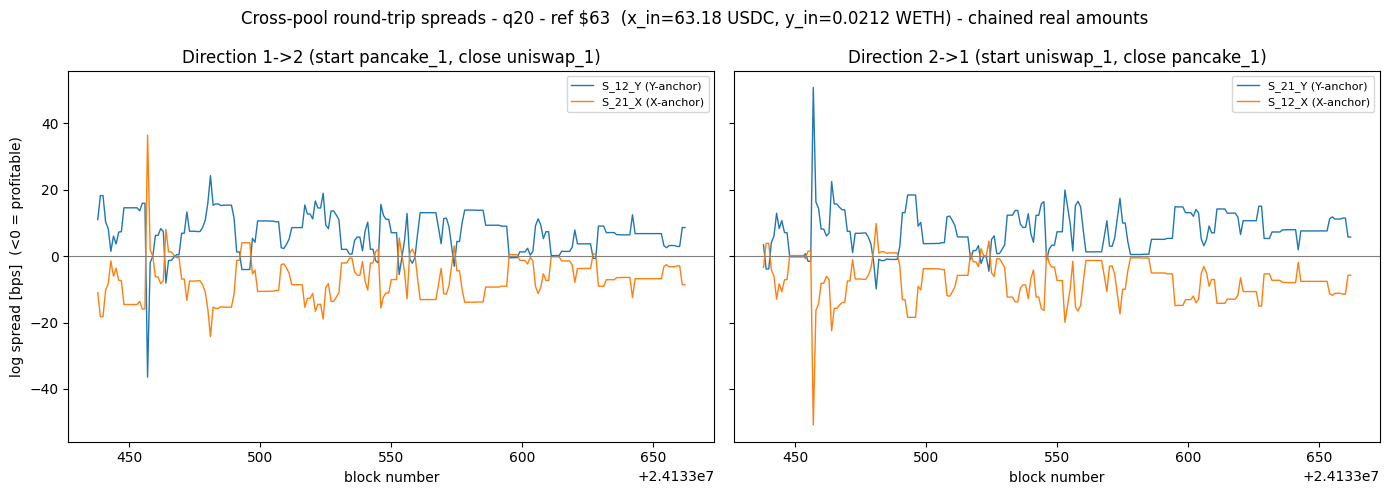

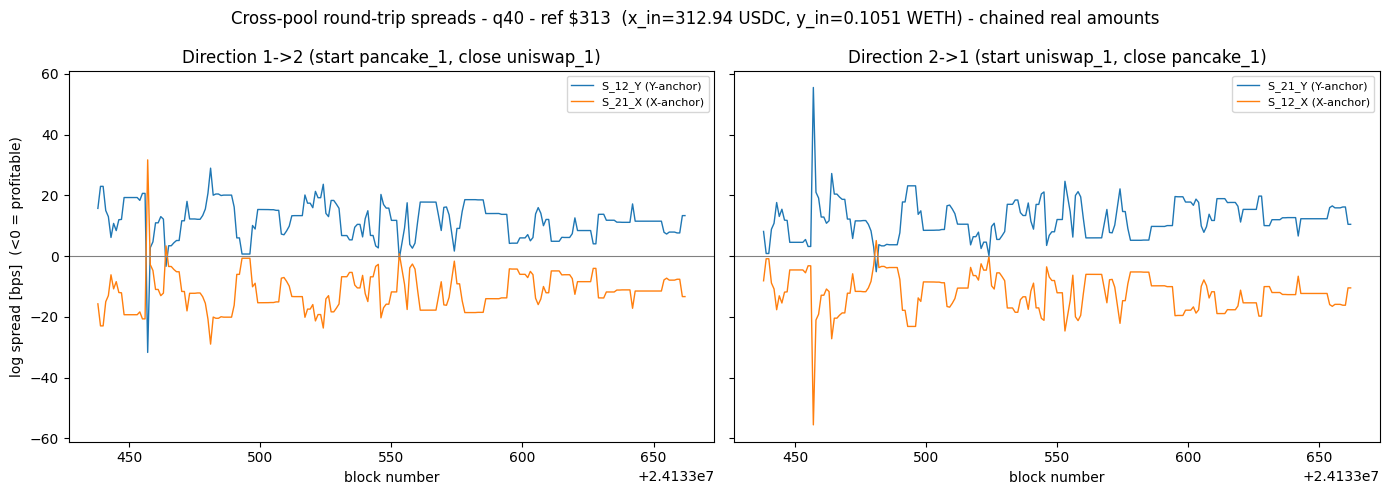

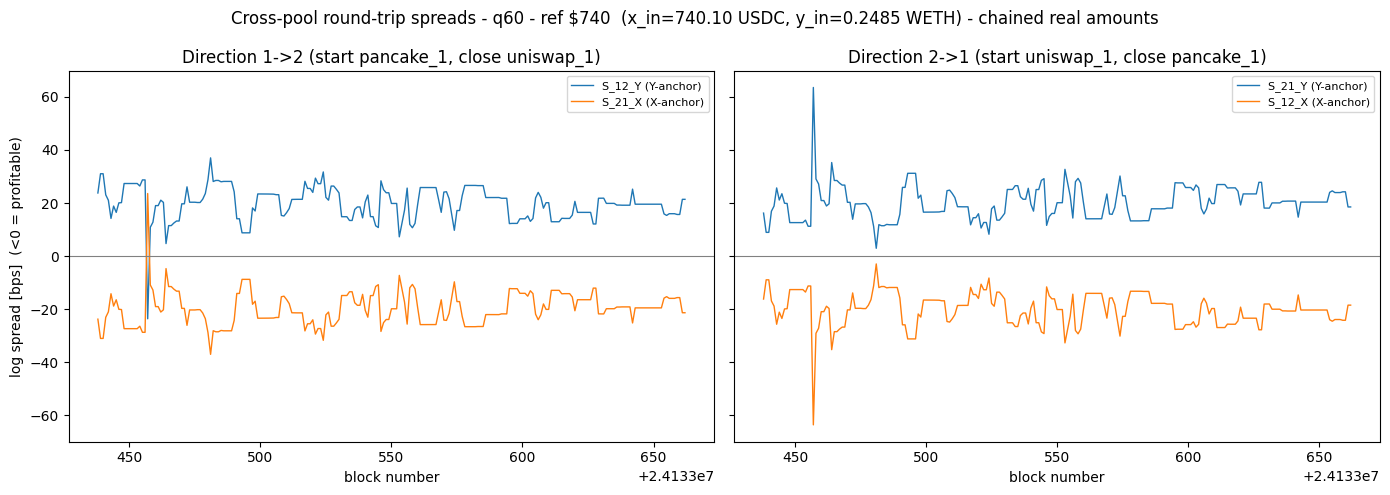

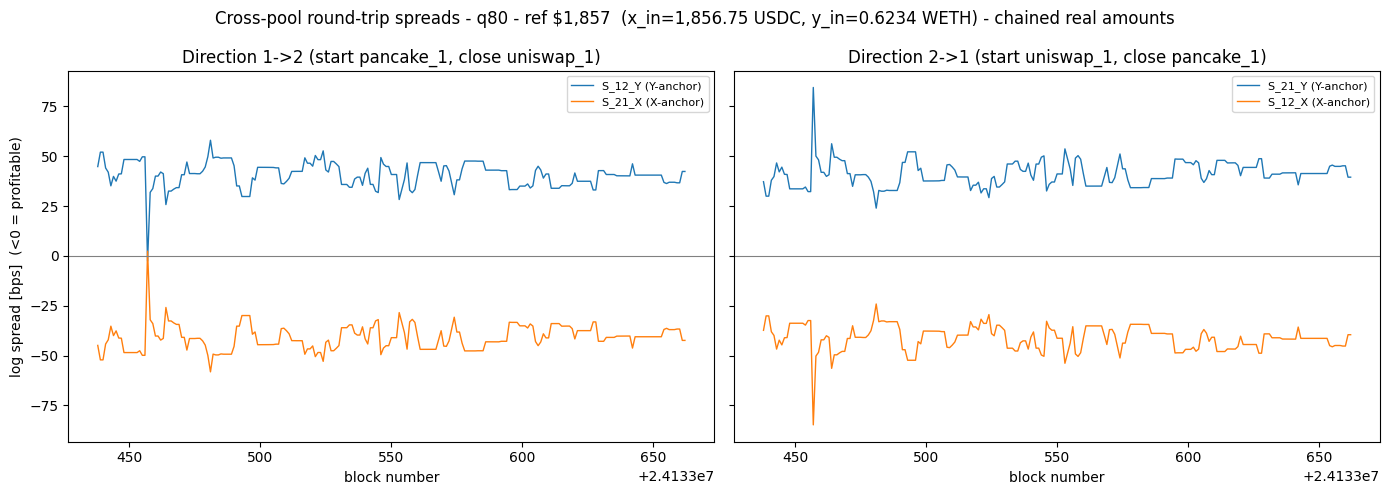

In [6]:
for q, Q in quantiles.items():
    plotting.plot_directional_spreads(pair, Q, f"Cross-pool round-trip spreads - q{int(q * 100)}")

## 3b. Custom trade size

Pass exactly one of `usd_amount` / `x_amount` (token0) / `y_amount` (token1).

In [ ]:
plotting.plot_custom_size(pair, usd_amount=10_000, title_prefix="Cross-pool round-trip spreads")

## 4. Arbitrage index (all pool pairs)

`all_pairs_gap_series` stores the per-block round-trip gap `Gap_t` (bps) for **every**
pool pair — intra-DEX (e.g. `uniswap_1_vs_uniswap_5`) as well as cross-DEX.
`arb_index["<poolA>_vs_<poolB>"]` is a blocks × trade-sizes frame; `arbitrage_index`
below summarises one pair across blocks.

In [11]:
arb_index = arbitrage.all_pairs_gap_series(pools, quantiles, S.token0, S.token1, price0, price1)
print("pairs:", list(arb_index))
arb_index["uniswap_1_vs_uniswap_5"].head()



pairs: ['uniswap_1_vs_uniswap_2', 'uniswap_1_vs_uniswap_3', 'uniswap_1_vs_uniswap_4', 'uniswap_1_vs_uniswap_5', 'uniswap_1_vs_pancake_1', 'uniswap_1_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_2_vs_uniswap_5', 'uniswap_2_vs_pancake_1', 'uniswap_2_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_5', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_4_vs_uniswap_5', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_5_vs_pancake_1', 'uniswap_5_vs_pancake_2', 'pancake_1_vs_pancake_2']


,0.2,0.4,0.6,0.8
block,,,,
24133438,2.431189,0.0,0.0,0.0
24133439,1.694893,0.0,0.0,0.0
24133440,1.694893,0.0,0.0,0.0
24133441,0.000000,0.0,0.0,0.0
24133442,0.000000,0.0,0.0,0.0


In [8]:
arbitrage.arbitrage_index(pair, quantiles)

,usd_ref,n_blocks,live_gap_share,mean_gap_bps,median_gap_bps,max_gap_bps,anchor_agreement
quantile,,,,,,,
0.2,63.195045,225,0.226667,0.558760,0.0,36.437869,1.0
0.4,313.031954,225,0.017778,0.182398,0.0,31.715172,1.0
0.6,740.312922,225,0.004444,0.105082,0.0,23.643396,1.0
0.8,1857.293128,225,0.004444,0.011437,0.0,2.573219,1.0


## 5. Any arbitrage in the sample?

Heatmap of the round-trip gap across all pairs and blocks, one panel per reference
trade size. Coloured cells are profitable round trips (after fees + slippage); a
near-blank map means little arbitrage at that size.

q20: 240 live (pair, block) cells of 4725 | max gap = 36.44 bps


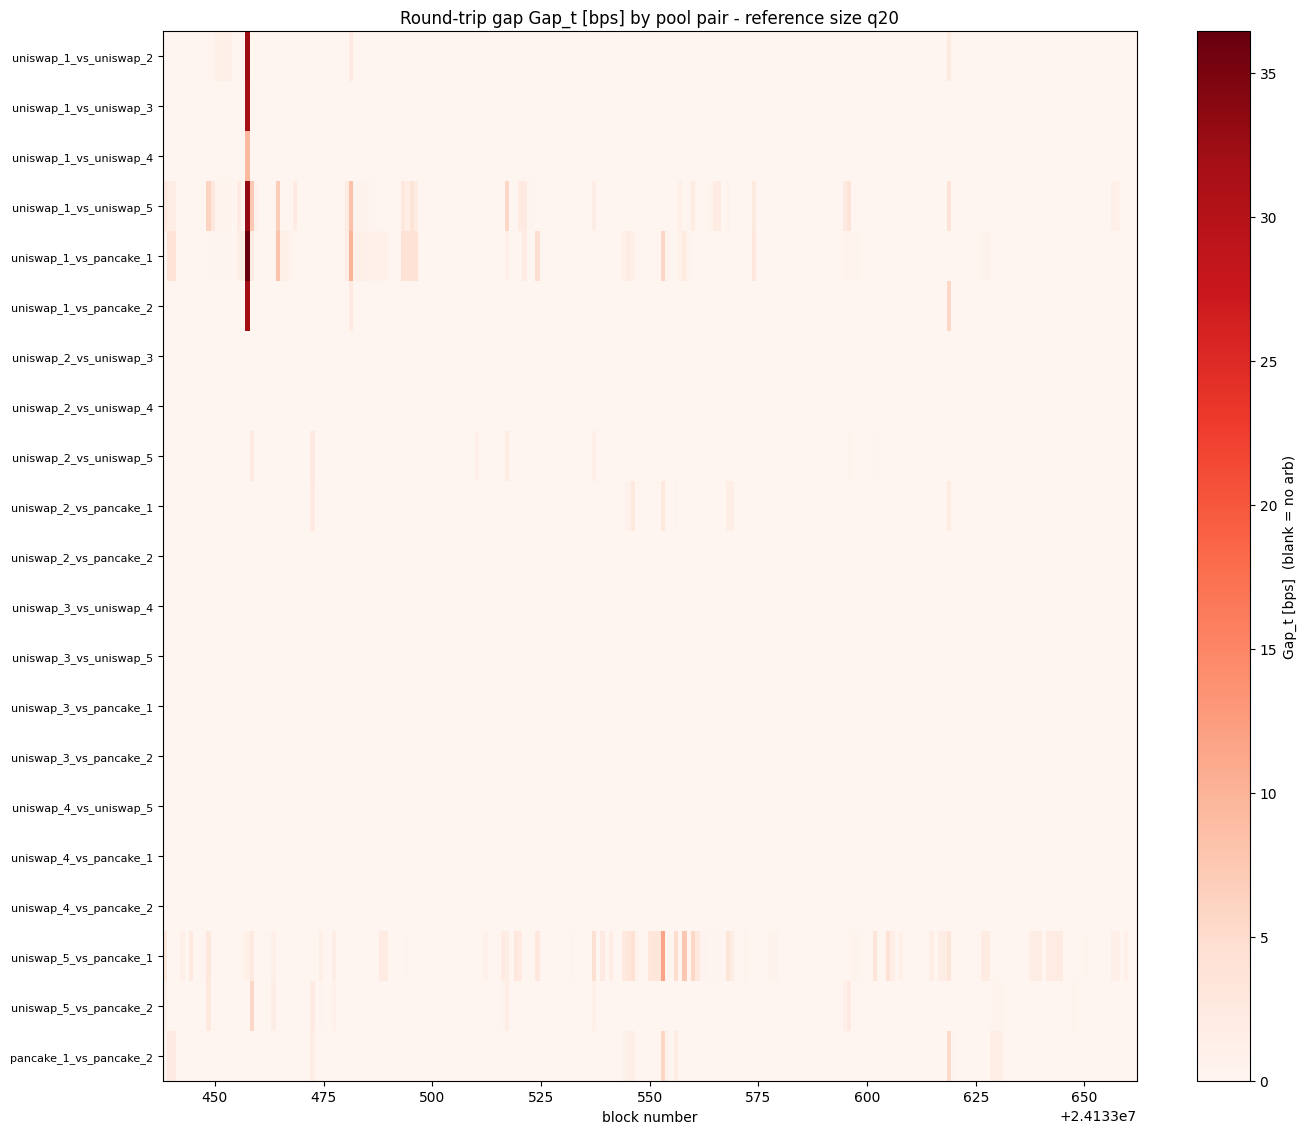

q40: 57 live (pair, block) cells of 4725 | max gap = 31.72 bps


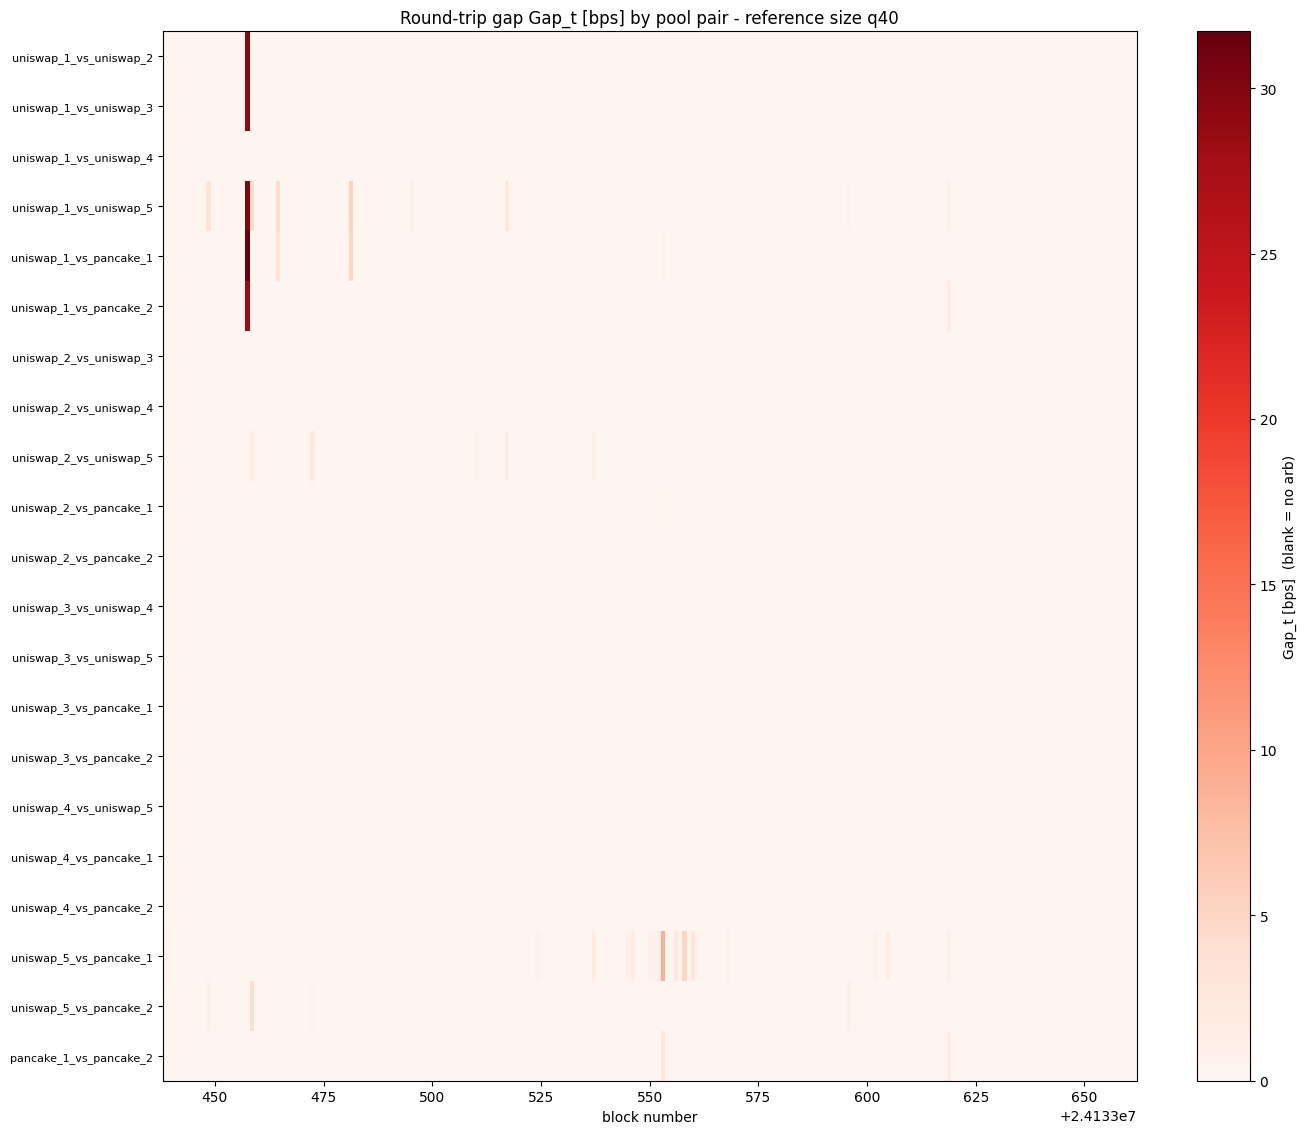

q60: 14 live (pair, block) cells of 4725 | max gap = 25.15 bps


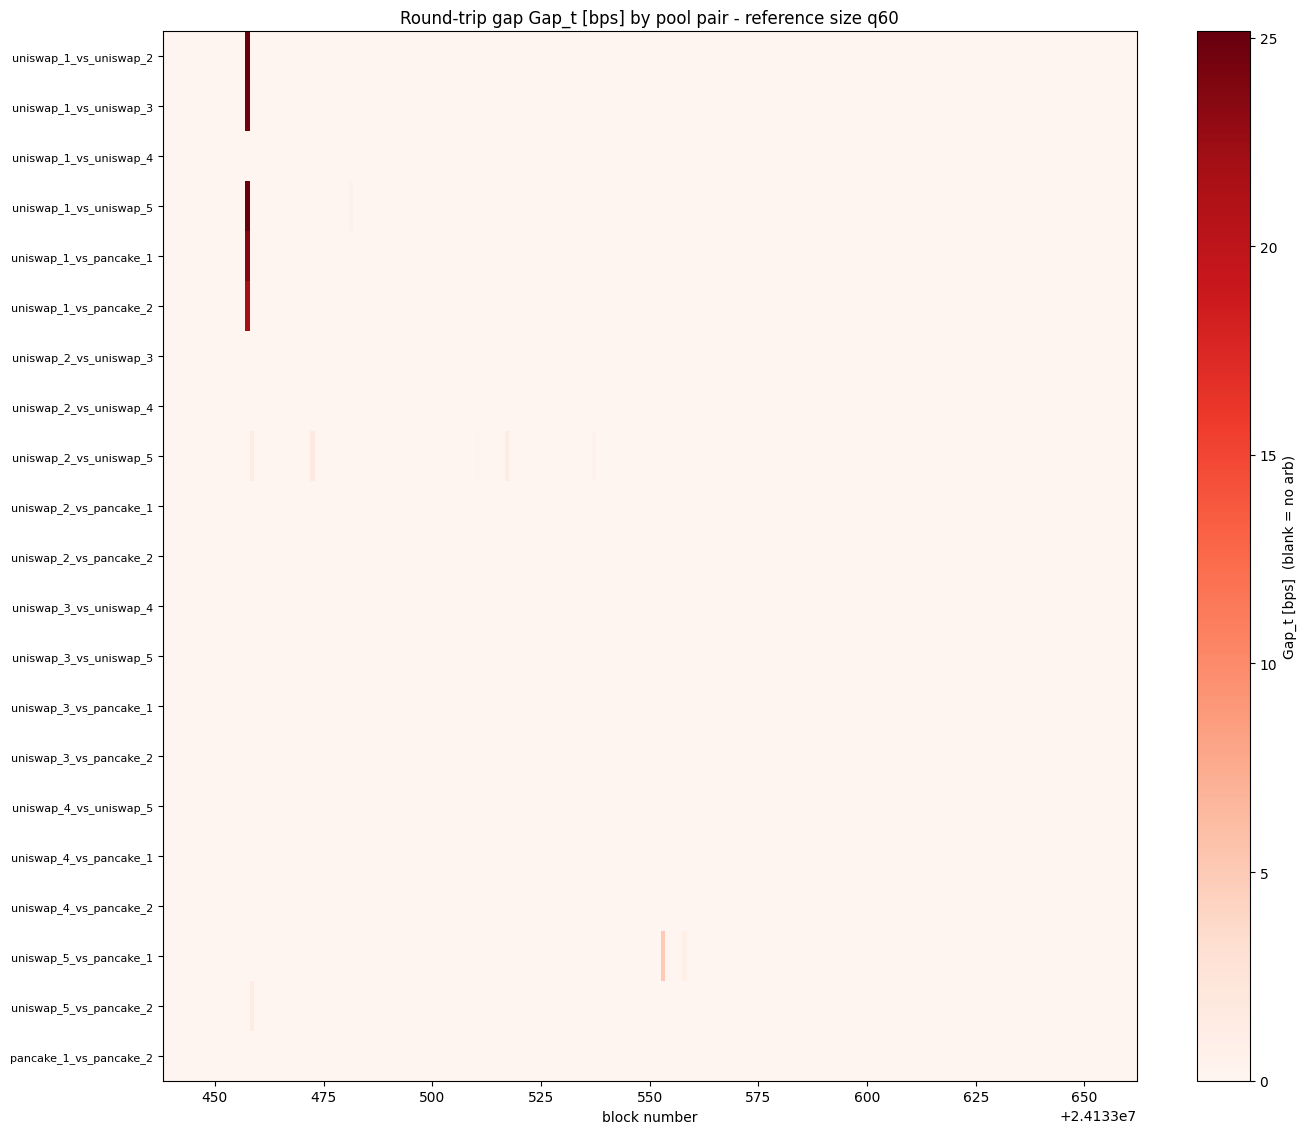

q80: 7 live (pair, block) cells of 4725 | max gap = 13.42 bps


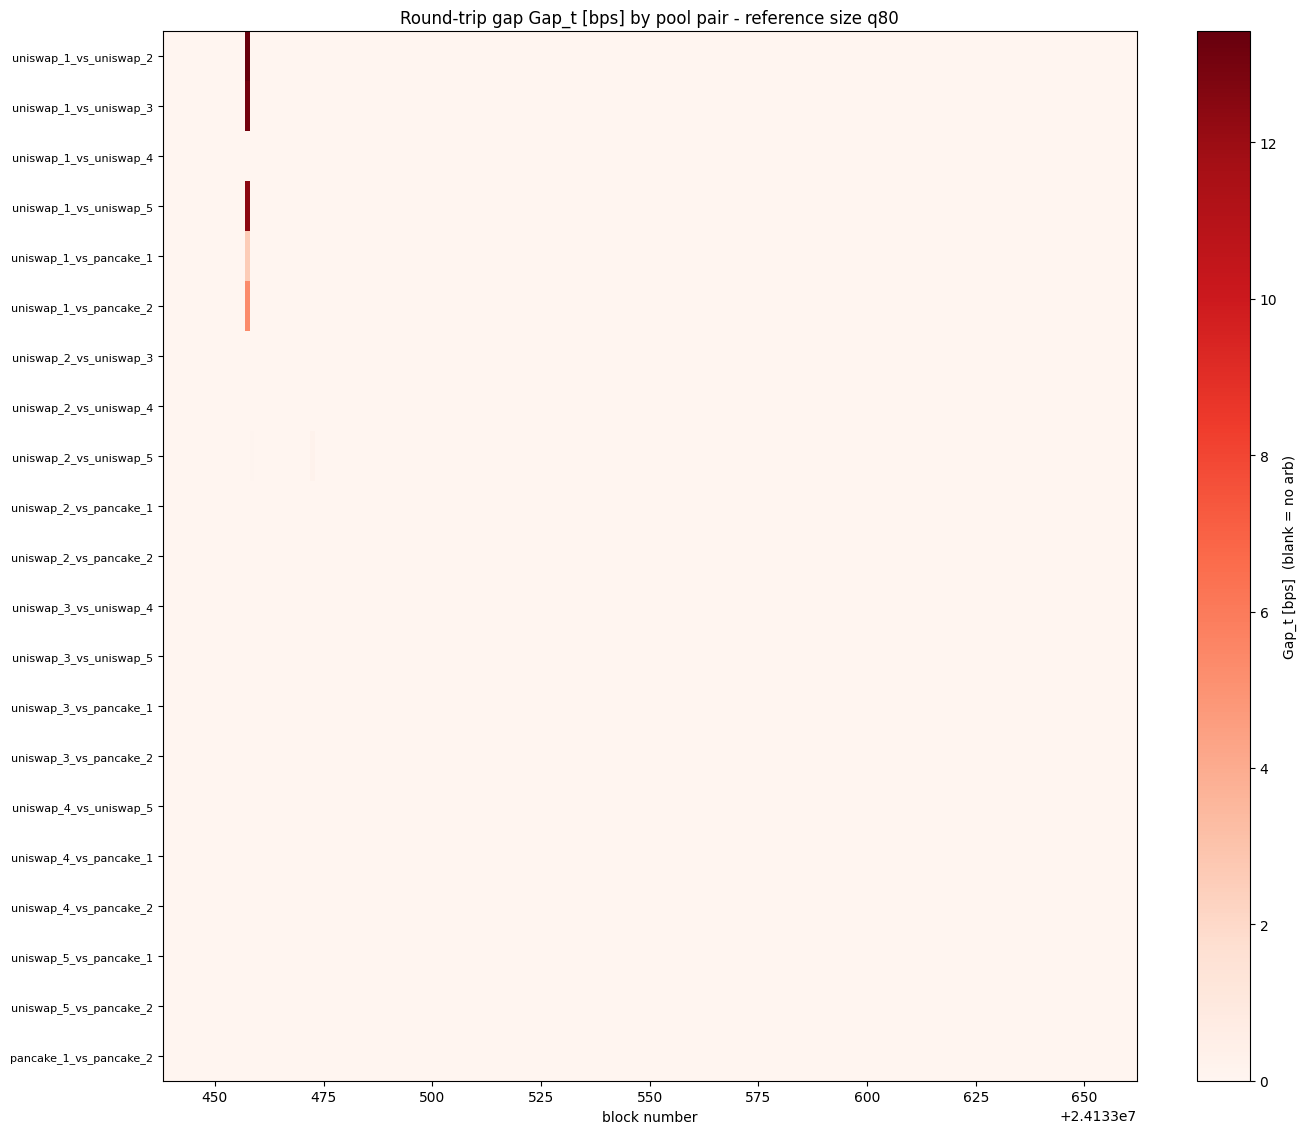

In [9]:
for q in quantiles.index:
    plotting.plot_arb_index(arb_index, q)